# Importing the Required Libraries

In [2]:
import argparse
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [48]:
import datetime

# Importing the Real estate Dataset

In [3]:
dataset = pd.read_csv('Real estate.csv')

In [4]:
dataset.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


<AxesSubplot:ylabel='Frequency'>

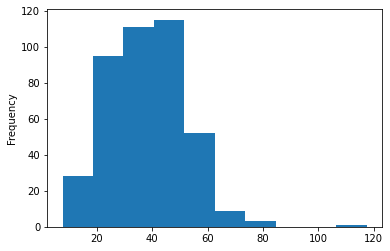

In [6]:
dataset['Y house price of unit area'].plot.hist()

In [7]:
Features = ['X2 house age','X3 distance to the nearest MRT station','X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = ['Y house price of unit area']

# Performing Train Test Split and experimenting different models

In [8]:
X_train, X_test, y_train, y_test = train_test_split(dataset[Features], dataset[target], test_size=0.10, random_state=42)

In [9]:
#Testing some Regression algorithms and checking their model performance and registering the same in the models_list

In [10]:
algorithm_list = [LinearRegression(), Lasso(alpha=1.0), KNeighborsRegressor(n_neighbors=5), DecisionTreeRegressor(), RandomForestRegressor()] 

In [11]:
scaler = StandardScaler()

In [12]:
scaler_y= StandardScaler()

In [13]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [41]:
tested_models = []
tested_models.clear()

print('Running Regression Models for Predicting RealEstate Prices')
print('================================================================')

for each_algorithm in algorithm_list: 
    print(f'Running {each_algorithm.__class__.__name__} algorithm')
    print('-------------------------------------')
    model = each_algorithm
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    RMSE_score_value = np.sqrt(mean_squared_error(y_true=y_test, y_pred=predictions))
    R2_score_value = r2_score(y_true=y_test, y_pred=predictions)
    
    print(f'RMSE : {RMSE_score_value}')
    print(f'R2_SCORE : {R2_score_value}')
    print('***************************************')
    print('\n')
    tested_models.append({each_algorithm.__class__.__name__:{'RMSE':RMSE_score_value, 'R2':R2_score_value}})
    
#PolynomialRegression
polyfeatures = PolynomialFeatures(degree=2,include_bias=False)
x_poly = polyfeatures.fit_transform(X_train)
lr = LinearRegression()
lr.fit(x_poly, y_train)
poly_predictions = lr.predict(polyfeatures.fit_transform(X_test))

poly_RMSE_score_value = np.sqrt(mean_squared_error(y_true=y_test, y_pred=poly_predictions))
poly_R2_score_value = r2_score(y_true=y_test, y_pred=poly_predictions)
    
print(f'RMSE : {poly_RMSE_score_value}')
print(f'R2_SCORE : {poly_R2_score_value}')
print('***************************************')
print('\n')
tested_models.append({'PolynomialRegression':{'RMSE':poly_RMSE_score_value, 'R2':poly_R2_score_value}})

#SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train_scaled)
scaled_ytest_predictions = svr.predict(X_test_scaled)
SVR_RMSE_score_value = np.sqrt(mean_squared_error(y_pred=scaler_y.inverse_transform(scaled_ytest_predictions.reshape(-1,1)), y_true = scaler_y.inverse_transform(y_test_scaled)))
SVR_R2_score_value= r2_score(y_pred=scaler_y.inverse_transform(scaled_ytest_predictions.reshape(-1,1)), y_true = scaler_y.inverse_transform(y_test_scaled))

print(f'RMSE : {SVR_RMSE_score_value}')
print(f'R2_SCORE : {SVR_R2_score_value}')
print('***************************************')
print('\n')
tested_models.append({svr.__class__.__name__:{'RMSE':SVR_RMSE_score_value, 'R2':SVR_R2_score_value}})

#Displaying the entire runned models with run parameters as a dataframe:

rows = [{"Model": name, **metrics} for item in tested_models for name, metrics in item.items()]
df = pd.DataFrame(rows)

# 2. Sort by RMSE (Ascending) and R2 (Descending)
df_sorted = df.sort_values(
    by=["RMSE", "R2"], 
    ascending=[True, False]
).reset_index(drop=True)

# 3. Clean up the output visual formatting
df_sorted[["RMSE", "R2"]] = df_sorted[["RMSE", "R2"]].round(4)

print(df_sorted)


#creating a csv database of models

try:
    with open('models_database.csv',mode='r') as file:
        pass
        
except FileNotFoundError:
    df_sorted.to_csv(path_or_buf='models_database.csv', index=False)

else:
    df_sorted.to_csv(path_or_buf='models_database.csv', mode="a", header="False", index="False")


Running Regression Models for Predicting RealEstate Prices
Running LinearRegression algorithm
-------------------------------------
RMSE : 8.42977033447786
R2_SCORE : 0.6374215449532815
***************************************


Running Lasso algorithm
-------------------------------------
RMSE : 8.915235187963223
R2_SCORE : 0.5944577391600316
***************************************


Running KNeighborsRegressor algorithm
-------------------------------------
RMSE : 8.250210386927803
R2_SCORE : 0.6527033805461046
***************************************


Running DecisionTreeRegressor algorithm
-------------------------------------
RMSE : 8.241399236516902
R2_SCORE : 0.6534448037431756
***************************************


Running RandomForestRegressor algorithm
-------------------------------------
RMSE : 6.861830293432568
R2_SCORE : 0.7597571591815203
***************************************


RMSE : 7.6877417679242095
R2_SCORE : 0.6984439245122904
**********************************

In [42]:
tested_models

[{'LinearRegression': {'RMSE': 8.42977033447786, 'R2': 0.6374215449532815}},
 {'Lasso': {'RMSE': 8.915235187963223, 'R2': 0.5944577391600316}},
 {'KNeighborsRegressor': {'RMSE': 8.250210386927803,
   'R2': 0.6527033805461046}},
 {'DecisionTreeRegressor': {'RMSE': 8.241399236516902,
   'R2': 0.6534448037431756}},
 {'RandomForestRegressor': {'RMSE': 6.861830293432568,
   'R2': 0.7597571591815203}},
 {'PolynomialRegression': {'RMSE': 7.6877417679242095,
   'R2': 0.6984439245122904}},
 {'SVR': {'RMSE': 7.481893908857658, 'R2': 0.7143767211867171}}]

# Testing a New Model - XGBoost and Deploying the model which have less RMSE

In [46]:
# which ever new model get trained,it is recorded in the model database with all required parameters.
# In this  case, since the data is not changed, the new model is compared with the existing model, since the existing model has the best scores
#if the new model score > existing model, then the new model is deployed, o.w existing model retained
# In real world case scenario, since the data is changed at regular intervals and model performance drops, all the trained models\\
# scores in the model database is compared and the best one is deployed

In [90]:
#1. Out of these trained models in the models_database.csv,deploying the model which has less RMSE score and high R2 score

models_df = pd.read_csv('models_database.csv',header='infer')
best_model = models_df.sort_values(by=['RMSE', 'R2'],ascending=[True, False]).reset_index(drop=True).head(1)

#creating a deployed_model database

best_model_df = pd.DataFrame(best_model)
best_model_df['deployment_Status'] = 'In_Production'
best_model_df['deployed_time'] = pd.Timestamp.now(tz='America/New_York').strftime('%Y-%m-%d %H:%M:%S')


try:
    with open('models_deployed.csv',mode='r') as file:
        pass
        
except FileNotFoundError:
    best_model_df.to_csv(path_or_buf='models_deployed.csv', index=False)

else:
    best_model_df.to_csv(path_or_buf='models_deployed.csv', mode="a", header="False", index="False")
    remov_status_df = pd.read_csv('models_deployed.csv')
    remov_status_df.sort_values(by ='deployed_time', ascending=False).reset_index(drop=True).iloc[0]['deployment_Status'] == 'In_Production'
    remov_status_df.sort_values(by ='deployed_time', ascending=False).reset_index(drop=True).iloc[1:]['deployment_Status'] == 'Archived'
    remov_status_df.to_csv('models_deployed.csv', index = False)